# Load Data

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
!pip install ucimlrepo

In [132]:
from ucimlrepo import fetch_ucirepo

# Load dataset
dataset = fetch_ucirepo(id=967)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

In [133]:
X = df.drop(columns=['label'])
y = df[['label']]

# fixing types
binary_cols = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]

df[binary_cols] = df[binary_cols].astype('category')
df['label'] = df['label'].astype('category')

categorical_df = X.select_dtypes(include='category') #### NOTICE: categorical_df is built from X only ----> for label use y!!!!!
numeric_df = X.drop(columns=categorical_df.columns)

In [134]:
print(f"df shape: {df.shape}")

df shape: (235795, 55)


# Data Cleaning

In [135]:
# how many missing values are in each column?
missing = df.isna().sum() # count NaNs per column
missing = missing[missing > 0].sort_values(ascending=False) # only show ones that actually have missing
if len(missing):
  print("Columns with missing values:")
  print(missing)
else:
  print("No NaN values anywhere")

# isna() doesn't catch empty/whitespace strings, so we check those separately for the object columns
for col in df.select_dtypes(include='object').columns:
  n_blank = df[col].astype(str).str.strip().eq('').sum() # count rows that are '' after stripping
  if n_blank:
    print(f"{col}: {n_blank} blank/whitespace-only strings")

No NaN values anywhere


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   URL                         235795 non-null  object  
 1   URLLength                   235795 non-null  int64   
 2   Domain                      235795 non-null  object  
 3   DomainLength                235795 non-null  int64   
 4   IsDomainIP                  235795 non-null  category
 5   TLD                         235795 non-null  object  
 6   URLSimilarityIndex          235795 non-null  float64 
 7   CharContinuationRate        235795 non-null  float64 
 8   TLDLegitimateProb           235795 non-null  float64 
 9   URLCharProb                 235795 non-null  float64 
 10  TLDLength                   235795 non-null  int64   
 11  NoOfSubDomain               235795 non-null  int64   
 12  HasObfuscation              235795 non-null  category
 13 

In [137]:
# duplicate detection: every URL is unique bc it's like a primary key
# so we check if any two rows are duplicate IF we ignore URL since these are same site fetched twice and could leak across train/test if undropped
n_dup_full   = df.duplicated().sum() # exact duplicates (URL included)
n_dup_no_url = df.drop(columns=['URL']).duplicated().sum() # duplicates ignoring URL
print(f"Exact duplicate rows: {n_dup_full}")
print(f"Duplicates ignoring URL col: {n_dup_no_url}")

# drop the ignore-URL duplicates --> keep the first occurrence
before = len(df)
df = df.drop_duplicates(subset=df.columns.difference(['URL'])).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows --> remaining: {len(df)}")

# rebuild the helper frames so the later cells use the cleaned df
X = df.drop(columns=['label']) # features only
y = df[['label']] # target only
categorical_df = X.select_dtypes(include='category') # any category-typed cols (binary flags)
numeric_df = X.drop(columns=categorical_df.columns) # everything else (numeric + the 4 string cols)


Exact duplicate rows: 0
Duplicates ignoring URL col: 91
Dropped 91 rows --> remaining: 235704


### Train/Val/Test Split to avoid Leakage

In [138]:
from sklearn.model_selection import train_test_split

# stratified 70/15/15 split
y_full = (df['label'] == 0).astype(int).values # 1 = phishing, 0 = legit
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y_full, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, stratify=y_full[idx_temp], random_state=42)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_val = df.iloc[idx_val].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

# targets (1 = phishing, 0 = legit)
y_train = (df_train['label'] == 0).astype(int).values
y_val = (df_val['label'] == 0).astype(int).values
y_test = (df_test['label'] == 0).astype(int).values

# features (without label) (these will get transformed step by step)
X_train = df_train.drop(columns=['label']).copy()
X_val = df_val.drop(columns=['label']).copy()
X_test = df_test.drop(columns=['label']).copy()

print(f"train: {len(df_train):>7d} ({y_train.mean():.2%} phishing)")
print(f"val: {len(df_val):>7d} ({y_val.mean():.2%} phishing)")
print(f"test: {len(df_test):>7d} ({y_test.mean():.2%} phishing)")

train:  164992 (42.79% phishing)
val:   35356 (42.79% phishing)
test:   35356 (42.79% phishing)


In [139]:
# outlier detection: flag rows with at least one feature more than 3 std devs from the mean (3-sigma rule)
from scipy.stats import zscore

num_only = df_train.drop(columns=['label']).select_dtypes(include=[np.number]) # int/float only i.e. skip URL/Domain/TLD/Title
z = np.abs(zscore(num_only, nan_policy='omit')) # absolute z-score per cell
extreme_rows = (z > 3).any(axis=1) # row is "extreme" if ANY feature is past |z|>3
print(f"Rows with at least one |z|>3 feature: {extreme_rows.sum()} ({extreme_rows.mean():.2%})")

Rows with at least one |z|>3 feature: 25208 (15.28%)


Phishing rate (overall): 42.79%
Phishing rate among |z|>3 outlier rows: 63.35%
Phishing rate among non-outlier rows: 39.08%
Lift among outliers: 1.48x

Phishing rate by max |z|-score bucket:
         mean   count
bucket               
0-1     0.145      62
1-2     0.340  111516
2-3     0.592   28206
3-5     0.565   14887
5+      0.732   10321


/tmp/ipykernel_16962/3125286999.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phish_by_bucket = (pd.DataFrame({'bucket': buckets, 'is_phish': (df_train['label']==0).astype(int).values}).groupby('bucket')['is_phish'].agg(['mean', 'count']))


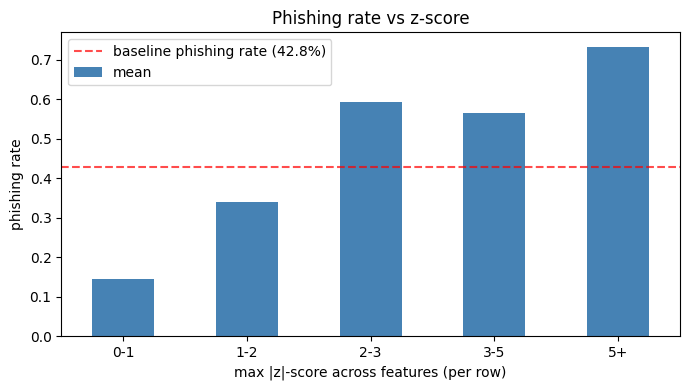

In [140]:
# proof that outliers actually contain phishing signal and aren't just noise to drop
# i.e. compare phishing rates among outlier rows vs. non-outlier rows.

phish_overall = (df_train['label'] == 0).mean() # baseline phishing rate
phish_outliers = (df_train.loc[extreme_rows, 'label'] == 0).mean() # phishing rate among |z|>3 rows
phish_normal = (df_train.loc[~extreme_rows, 'label'] == 0).mean() # phishing rate among the rest

print(f"Phishing rate (overall): {phish_overall:.2%}")
print(f"Phishing rate among |z|>3 outlier rows: {phish_outliers:.2%}")
print(f"Phishing rate among non-outlier rows: {phish_normal:.2%}")
print(f"Lift among outliers: {phish_outliers / phish_overall:.2f}x")

# bucket rows by the maximum |z|-score across features and plot phishing rate per bucket
# if phishing rate climbs as rows get more extreme, outliers are signal, not noise
zmax = z.max(axis=1) # max |z| per row
buckets = pd.cut(zmax, bins=[0, 1, 2, 3, 5, np.inf], labels=['0-1', '1-2', '2-3', '3-5', '5+'])
phish_by_bucket = (pd.DataFrame({'bucket': buckets, 'is_phish': (df_train['label']==0).astype(int).values}).groupby('bucket')['is_phish'].agg(['mean', 'count']))
print(f"\nPhishing rate by max |z|-score bucket:")
print(phish_by_bucket.round(3))

# bar chart with baseline marked -- the steeper the climb, the more signal in the outliers
fig, ax = plt.subplots(figsize=(7, 4))
phish_by_bucket['mean'].plot(kind='bar', color='steelblue', ax=ax)
ax.axhline(phish_overall, color='red', linestyle='--', alpha=0.7,
           label=f'baseline phishing rate ({phish_overall:.1%})')
ax.set_xlabel('max |z|-score across features (per row)')
ax.set_ylabel('phishing rate')
ax.set_title('Phishing rate vs z-score')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

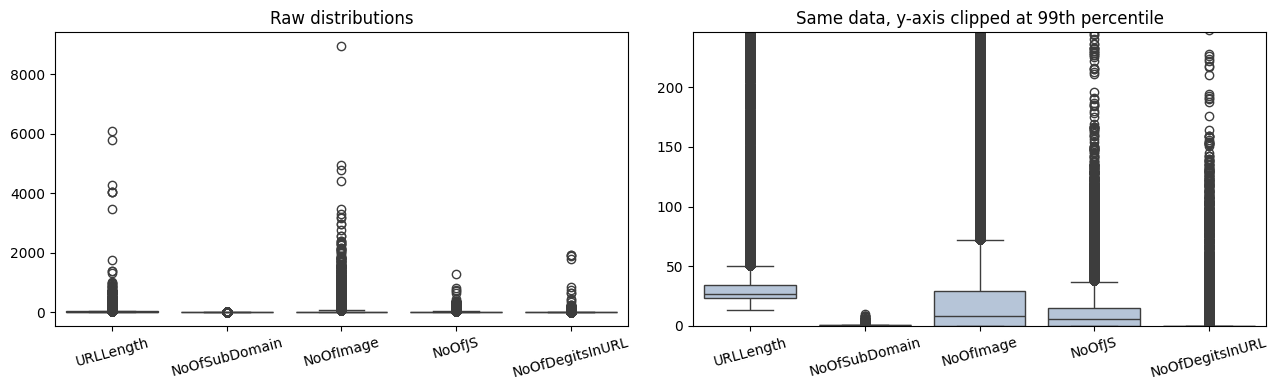

In [141]:
# boxplot of a few heavy-tailed numeric features
candidates = ['URLLength', 'NoOfSubDomain', 'NoOfImage', 'NoOfJS', 'NoOfDegitsInURL']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# left: raw boxplot
sns.boxplot(data=df_train[candidates], ax=axes[0], color='lightsteelblue')
axes[0].set_title('Raw distributions')
axes[0].tick_params(axis='x', rotation=15)

# right: same data, y-axis clipped at the 99th percentile so typical values become visible
sns.boxplot(data=df_train[candidates], ax=axes[1], color='lightsteelblue')
upper_lim = df_train[candidates].quantile(0.99).max()
axes[1].set_ylim(0, upper_lim)
axes[1].set_title('Same data, y-axis clipped at 99th percentile')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Data Transformation

In [142]:
from scipy.stats import boxcox, yeojohnson

# numeric columns to transform (excludes URL/Domain/TLD/Title which are objects)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Skew on TRAIN (we fit transformations on train only):")
print(X_train[numeric_cols].skew())

# fit lambdas + z-score statistics on TRAIN, then apply the same parameters to val/test
fitted_lambdas = {} # col -> (method, lambda)
fitted_zscore  = {} # col -> (train_mean, train_std)

for col in numeric_cols:
  train_vals = X_train[col].values
  skew_val   = X_train[col].skew()

  # apply Yeo-Johnson if heavily skewed and contains zeros/negatives;
  # Box-Cox if heavily skewed and strictly positive; otherwise pass through
  if abs(skew_val) > 1:
    if (train_vals <= 0).any():
      tr_train, lam = yeojohnson(train_vals) # fit lambda on train
      fitted_lambdas[col] = ('yeojohnson', lam)
      tr_val = yeojohnson(X_val[col].values,  lmbda=lam) # apply same lambda
      tr_test = yeojohnson(X_test[col].values, lmbda=lam)
    else:
      tr_train, lam = boxcox(train_vals)
      fitted_lambdas[col] = ('boxcox', lam)
      tr_val = boxcox(X_val[col].values,  lmbda=lam)
      tr_test = boxcox(X_test[col].values, lmbda=lam)
  else:
    # mild skew -- pass through unchanged (still gets z-scored below)
    fitted_lambdas[col] = ('identity', None)
    tr_train, tr_val, tr_test = train_vals, X_val[col].values, X_test[col].values

  # z-score using TRAIN mean / std (btw it will give same result for already-z-scored columns so no negative impact)
  train_mean = tr_train.mean()
  train_std = tr_train.std() if tr_train.std() > 0 else 1.0
  fitted_zscore[col] = (train_mean, train_std)

  X_train[col] = (tr_train - train_mean) / train_std
  X_val[col] = (tr_val   - train_mean) / train_std
  X_test[col] = (tr_test  - train_mean) / train_std

print("\nSkew on TRAIN after transformation:")
print(X_train[numeric_cols].skew())

Skew on TRAIN (we fit transformations on train only):
URLLength                      57.264480
DomainLength                    2.517905
URLSimilarityIndex             -0.991006
CharContinuationRate           -1.132152
TLDLegitimateProb               0.073913
URLCharProb                    -1.063622
TLDLength                       1.632122
NoOfSubDomain                   1.775444
NoOfObfuscatedChar            198.261372
ObfuscationRatio               37.684803
NoOfLettersInURL               65.742963
LetterRatioInURL               -0.064665
NoOfDegitsInURL                92.495384
DegitRatioInURL                 3.255045
NoOfEqualsInURL               115.430154
NoOfQMarkInURL                  8.205854
NoOfAmpersandInURL            105.228828
NoOfOtherSpecialCharsInURL     50.557468
SpacialCharRatioInURL           1.182229
LineOfCode                     55.457678
LargestLineLength              48.807062
DomainTitleMatchScore          -0.012007
URLTitleMatchScore             -0.092324
NoO

In [143]:
# TLD encoding: top-20 TLDs from TRAIN, bucket the rest as 'OTHER', then one-hot encode
# val/test sets get the same column set even if they contain TLDs not seen in train

TOP_K_TLD = 20
top_tlds = X_train['TLD'].value_counts().head(TOP_K_TLD).index.tolist()
all_categories = top_tlds + ['OTHER']

def encode_tld(df_split, top_tlds, categories):
  out = df_split.copy()
  out['TLD'] = out['TLD'].where(out['TLD'].isin(top_tlds), other='OTHER') # bucket rare TLDs
  out['TLD'] = pd.Categorical(out['TLD'], categories=categories) # lock in the category set
  out = pd.get_dummies(out, columns=['TLD'], prefix='TLD', drop_first=False)
  bool_cols = out.select_dtypes(include='bool').columns
  out[bool_cols] = out[bool_cols].astype(int) # cast bool -> int so select_dtypes(np.number) keeps them
  return out

X_train = encode_tld(X_train, top_tlds, all_categories)
X_val = encode_tld(X_val,   top_tlds, all_categories)
X_test = encode_tld(X_test,  top_tlds, all_categories)

print(f"X_train shape after TLD encoding: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(X_train[numeric_cols].agg(['mean', 'std']).round(3).T.head())

X_train shape after TLD encoding: (164992, 74)
X_val shape: (35356, 74)
X_test shape: (35356, 74)
                      mean  std
URLLength             -0.0  1.0
DomainLength           0.0  1.0
URLSimilarityIndex    -0.0  1.0
CharContinuationRate  -0.0  1.0
TLDLegitimateProb      0.0  1.0


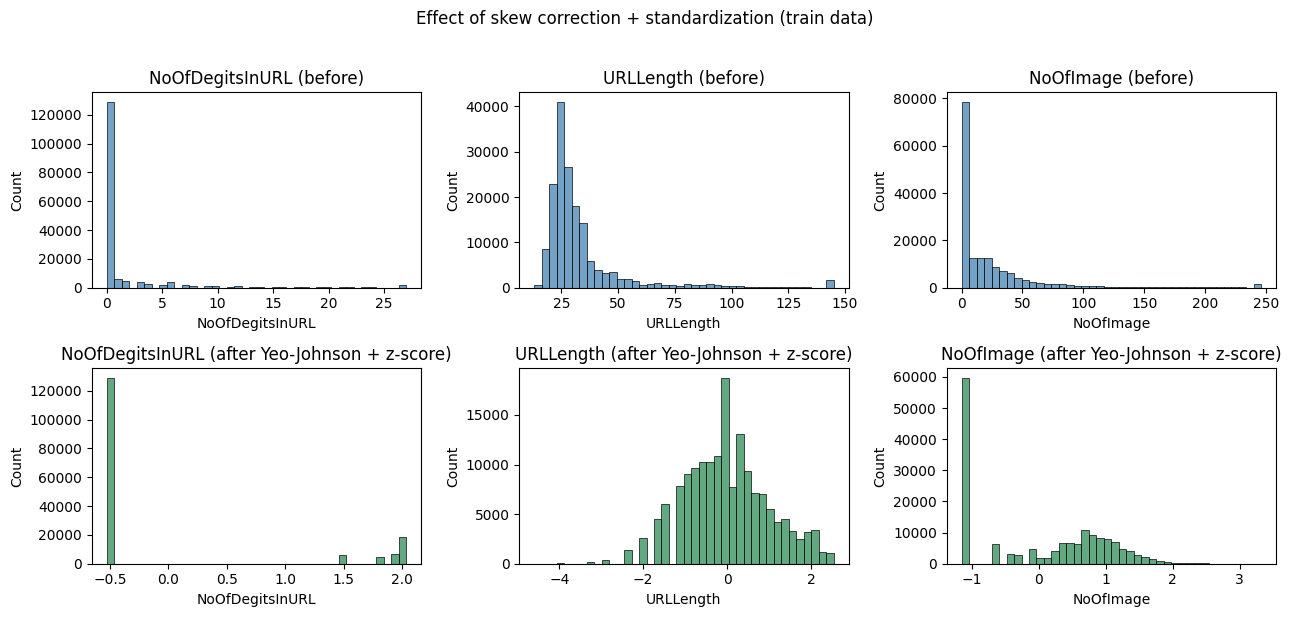

In [144]:
# histograms before vs. after transformation, calculated on TRAIN only
# df_train still has the pre-transformation values while X_train has the post-transformation z-scored ones

features_to_plot = ['NoOfDegitsInURL', 'URLLength', 'NoOfImage']

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for col_idx, feat in enumerate(features_to_plot):
  # BEFORE: clip at the 99th percentile so the bulk of the distribution is visible
  upper = df_train[feat].quantile(0.99)
  sns.histplot(df_train[feat].clip(upper=upper), bins=40, ax=axes[0, col_idx], color='steelblue')
  axes[0, col_idx].set_title(f'{feat} (before)')

  # AFTER: the transformed + z-scored values from X_train
  sns.histplot(X_train[feat], bins=40, ax=axes[1, col_idx], color='seagreen')
  axes[1, col_idx].set_title(f'{feat} (after Yeo-Johnson + z-score)')

plt.suptitle('Effect of skew correction + standardization (train data)', y=1.02)
plt.tight_layout()
plt.show()

# Feature Selection

In [145]:
# variance threshold: drop features that are essentially constant in original TRAIN data
# IMPORTANT: we read variances from df_train (pre-transform), not X_train (post-transform)
# bc after Yeo-Johnson + z-score, every column has var ~ 1, so a post-transform check is ~ useless
from sklearn.feature_selection import VarianceThreshold

# only do on the numeric/encoded portion of X (skips URL/Domain/Title which are strings)
X_train_numeric = X_train.select_dtypes(include=[np.number]).copy()
X_val_numeric = X_val.select_dtypes(include=[np.number]).copy()
X_test_numeric = X_test.select_dtypes(include=[np.number]).copy()

# look at the original variances on TRAIN
pre_transform_var = df_train.select_dtypes(include=[np.number]).var().sort_values()
print("Five lowest pre-transform variances (train):")
print(pre_transform_var.head().round(6))

# drop columns whose ORIGINAL train variance is below 1e-4 (i.e. roughly constant)
near_constant = pre_transform_var[pre_transform_var < 1e-4].index.tolist()
near_constant = [c for c in near_constant if c in X_train_numeric.columns]

print()
if near_constant:
  print(f"Dropping {len(near_constant)} feature(s) that were near-constant in train:")
  for col in near_constant:
    print(f"--> {col}: original var = {pre_transform_var[col]:.6f}")
  X_train_numeric = X_train_numeric.drop(columns=near_constant)
  X_val_numeric   = X_val_numeric.drop(columns=near_constant)
  X_test_numeric  = X_test_numeric.drop(columns=near_constant)
else:
  print("No features below the variance threshold.")

print(f"Variance threshold: kept {X_train_numeric.shape[1]} features")

Five lowest pre-transform variances (train):
ObfuscationRatio         0.000013
URLCharProb              0.000112
SpacialCharRatioInURL    0.001045
DegitRatioInURL          0.004993
LetterRatioInURL         0.015181
dtype: float64

Dropping 1 feature(s) that were near-constant in train:
--> ObfuscationRatio: original var = 0.000013
Variance threshold: kept 51 features


In [146]:
# correlation filter: if two features have |r| > 0.95 they carry essentially the same information

corr = X_train_numeric.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # upper triangle only

high_corr = upper.stack().reset_index()
high_corr.columns = ['feature_a', 'feature_b', 'corr']
high_corr = high_corr[high_corr['corr'] > 0.95].sort_values('corr', ascending=False)

print(f"Pairs of features with |r| > 0.95 ({len(high_corr)} pairs):")
for _, row in high_corr.iterrows():
  print(f"r={row['corr']:.3f}: {row['feature_a']:32s} <-> {row['feature_b']}")

# drop one feature from each correlated pair
to_drop_corr = [col for col in upper.columns if (upper[col] > 0.95).any()]
print(f"\nDropping {len(to_drop_corr)} features (one from each pair): {to_drop_corr}")

X_train_numeric = X_train_numeric.drop(columns=to_drop_corr)
X_val_numeric = X_val_numeric.drop(columns=to_drop_corr)
X_test_numeric = X_test_numeric.drop(columns=to_drop_corr)
print(f"Remaining features: {X_train_numeric.shape[1]}")

Pairs of features with |r| > 0.95 (4 pairs):
r=0.997: TLDLegitimateProb                <-> TLD_com
r=0.994: NoOfDegitsInURL                  <-> DegitRatioInURL
r=0.961: DomainTitleMatchScore            <-> URLTitleMatchScore
r=0.953: URLLength                        <-> NoOfLettersInURL

Dropping 4 features (one from each pair): ['NoOfLettersInURL', 'DegitRatioInURL', 'URLTitleMatchScore', 'TLD_com']
Remaining features: 47


In [147]:
# mutual information ranking on the full TRAIN set
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train_numeric, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train_numeric.columns).sort_values(ascending=False)

print("Top 15 features by mutual information (train):")
print(mi_series.head(15).round(4))

Top 15 features by mutual information (train):
URLSimilarityIndex            0.6718
LineOfCode                    0.6009
NoOfExternalRef               0.5647
NoOfImage                     0.5494
NoOfSelfRef                   0.5332
NoOfJS                        0.5069
LargestLineLength             0.4858
NoOfCSS                       0.4526
LetterRatioInURL              0.3808
NoOfOtherSpecialCharsInURL    0.2426
DomainTitleMatchScore         0.2050
SpacialCharRatioInURL         0.2048
TLDLegitimateProb             0.1863
NoOfDegitsInURL               0.1788
NoOfEmptyRef                  0.1742
dtype: float64


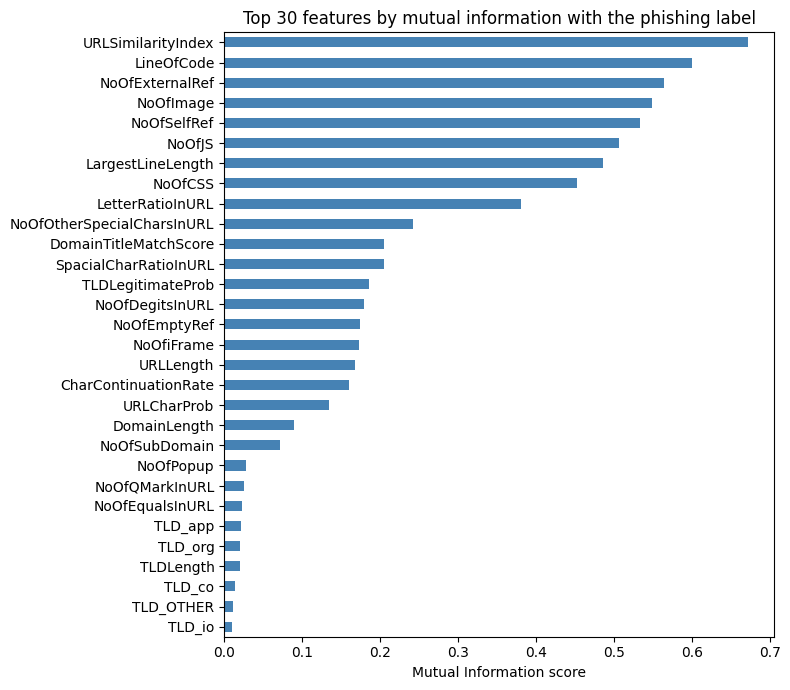

In [148]:
# bar chart of top-30 MI scores so we can somewhat guage where signal drops off
N_VIZ = 30
plt.figure(figsize=(8, 7))
mi_series.head(N_VIZ).iloc[::-1].plot(kind='barh', color='steelblue') # reverse so highest is on top
plt.xlabel('Mutual Information score')
plt.title(f'Top {N_VIZ} features by mutual information with the phishing label')
plt.tight_layout()
plt.show()

In [149]:
# cumulative MI threshold: keep features in MI rank order until cum MI >= MI_THRESHOLD.
MI_THRESHOLD = 0.95 # fraction of total MI to keep

cum_mi = mi_series.cumsum() / mi_series.sum() # fraction of total MI captured by the top-k features
mask = cum_mi.values >= MI_THRESHOLD # boolean: True at the first k where threshold is met
TOP_N = int(np.argmax(mask) + 1) if mask.any() else len(cum_mi) # smallest k that hits threshold

print(f"Total MI mass across {len(mi_series)} features: {mi_series.sum():.3f}")
print(f"At k = {TOP_N}, cumulative MI = {cum_mi.iloc[TOP_N-1]:.3f} (>= {MI_THRESHOLD:.0%})")
print(f"\nKeeping {TOP_N} features")

Total MI mass across 47 features: 6.964
At k = 20, cumulative MI = 0.957 (>= 95%)

Keeping 20 features


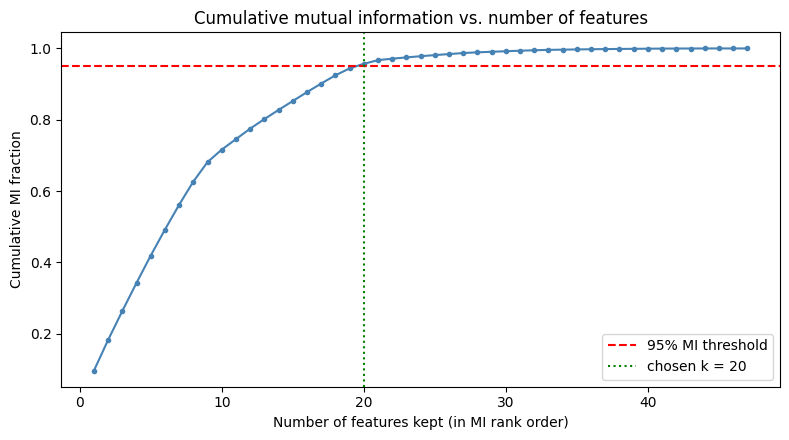

In [150]:
# plot cumulative MI curve with the threshold and chosen K marked
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_mi) + 1), cum_mi.values, marker='.', color='steelblue')
plt.axhline(MI_THRESHOLD, color='red', linestyle='--', label=f'{MI_THRESHOLD:.0%} MI threshold')
plt.axvline(TOP_N, color='green', linestyle=':', label=f'chosen k = {TOP_N}')
plt.xlabel('Number of features kept (in MI rank order)')
plt.ylabel('Cumulative MI fraction')
plt.title('Cumulative mutual information vs. number of features')
plt.legend()
plt.tight_layout()
plt.show()

In [151]:
# apply train-derived TOP_N selection to all three splits
selected_features = mi_series.head(TOP_N).index.tolist()

X_train_selected = X_train_numeric[selected_features]
X_val_selected = X_val_numeric[selected_features]
X_test_selected = X_test_numeric[selected_features]

print(f"Selected feature set ({TOP_N} features, derived from train MI ranking):")
for i, f in enumerate(selected_features, 1):
  print(f"{i:2d}. {f:35s} MI={mi_series[f]:.4f}")

Selected feature set (20 features, derived from train MI ranking):
 1. URLSimilarityIndex                  MI=0.6718
 2. LineOfCode                          MI=0.6009
 3. NoOfExternalRef                     MI=0.5647
 4. NoOfImage                           MI=0.5494
 5. NoOfSelfRef                         MI=0.5332
 6. NoOfJS                              MI=0.5069
 7. LargestLineLength                   MI=0.4858
 8. NoOfCSS                             MI=0.4526
 9. LetterRatioInURL                    MI=0.3808
10. NoOfOtherSpecialCharsInURL          MI=0.2426
11. DomainTitleMatchScore               MI=0.2050
12. SpacialCharRatioInURL               MI=0.2048
13. TLDLegitimateProb                   MI=0.1863
14. NoOfDegitsInURL                     MI=0.1788
15. NoOfEmptyRef                        MI=0.1742
16. NoOfiFrame                          MI=0.1736
17. URLLength                           MI=0.1679
18. CharContinuationRate                MI=0.1605
19. URLCharProb                  

# Feature Extraction (Creation)

In [152]:
# domain-knowledge feature extraction from raw URL / Domain / Title strings

import re, math
from collections import Counter

# words common in credential-bait phishing URLs
SUSPICIOUS_KEYWORDS = ['login', 'signin', 'sign-in', 'verify', 'verification', 'secure', 'security',
                       'account', 'update', 'confirm', 'banking', 'webscr', 'admin', 'support',
                       'password', 'wallet', 'recover', 'auth', 'invoice', 'billing']

# popular brands that attackers may want to target bc they are somewhat high-value or well-known
BRAND_KEYWORDS = ['paypal', 'amazon', 'apple', 'microsoft', 'google', 'facebook',
                  'instagram', 'twitter', 'netflix', 'ebay', 'chase', 'wellsfargo',
                  'bankofamerica', 'citibank', 'hsbc', 'dropbox', 'linkedin']

# pre-compile regex patterns once (to avoid rebuilding them inside the per-row loop)
SUSP_RE = re.compile('|'.join(map(re.escape, SUSPICIOUS_KEYWORDS)))
BRAND_RE = re.compile('|'.join(map(re.escape, BRAND_KEYWORDS)))
IP_RE = re.compile(r'^\d{1,3}(?:\.\d{1,3}){3}') # bare IPv4 hostname
SCHEME_RE = re.compile(r'^https?://', re.IGNORECASE) # to strip http(s):// before parsing

# Shannon entropy of a string: random-looking domains have higher entropy than English-y ones
def shannon_entropy(s):
  if not s:
    return 0.0
  n = len(s)
  counts = Counter(s) # character frequencies
  return -sum((c / n) * math.log2(c / n) for c in counts.values())

# Pull engineered features out of a single (url, domain, title) row
def extract(url, domain, title):
  # cast to string in case anything is NaN / non-string
  url = url if isinstance(url, str)    else ''
  domain = domain if isinstance(domain, str) else ''
  title  = title if isinstance(title, str)  else ''
  u = url.lower() # lowercase once for keyword matching

  # split URL into host vs. path so we can analyze them separately
  no_scheme = SCHEME_RE.sub('', u) # drop the http(s):// prefix
  host_part, _, path_part = no_scheme.partition('/') # everything before / is the host
  host = host_part.split(':', 1)[0] # strip explicit :port for structural counts

  # character composition stats on the host
  n_letters = sum(c.isalpha() for c in host) # how many letters
  n_digits  = sum(c.isdigit() for c in host) # how many digits
  n_vowels  = sum(c in 'aeiou' for c in host) # how many vowels
  letters_safe = max(n_letters, 1) # prevent div-by-zero on weird hosts

  # brand-in-subdomain check (e.g. "paypal.com.evil.example")
  parts = host.split('.')
  has_brand_sub = 0
  if len(parts) >= 3: # only meaningful if there's a subdomain
    subdomain = '.'.join(parts[:-2]) # everything LEFT of the registrable domain
    if BRAND_RE.search(subdomain):
      has_brand_sub = 1

  return {
    # binary red-flags from the URL string itself
    'fe_has_ip': 1 if IP_RE.match(host_part) else 0, # bare IP instead of hostname
    'fe_has_at': 1 if '@' in u else 0, # @ trick to mask the real host
    'fe_has_double_slash_path': 1 if '//' in path_part else 0, # second // after the scheme
    'fe_has_punycode': 1 if 'xn--' in u else 0, # IDN -> homograph attack
    'fe_has_port': 1 if re.search(r':\d', host_part) else 0, # explicit non-standard port
    # structural counts on the host
    'fe_num_hyphens_host': host.count('-'), # phishing hosts skew hyphen-heavy
    'fe_num_dots_host': host.count('.'), # subdomain depth
    # keyword detection
    'fe_n_suspicious_kw': len(SUSP_RE.findall(u)), # how many bait words appear
    'fe_has_brand_kw_in_subdomain': has_brand_sub, # spoofed brand left of root
    # entropy / randomness
    'fe_url_entropy': shannon_entropy(u),
    'fe_host_entropy': shannon_entropy(host),
    # composition ratios
    'fe_digit_letter_ratio_host': n_digits / letters_safe,
    'fe_vowel_ratio_host': n_vowels / letters_safe,
    # path / query structure
    'fe_path_length': len(path_part),
    'fe_num_path_segments': path_part.count('/'),
    'fe_has_query': 1 if '?' in u else 0,
    'fe_has_fragment': 1 if '#' in u else 0,
    # title features
    'fe_title_length': len(title),
    'fe_title_word_count': len(title.split()),
    'fe_title_empty': 1 if len(title.strip()) == 0 else 0,
    'fe_title_has_brand': 1 if BRAND_RE.search(title.lower()) else 0,
  }

In [153]:
# apply extractor per split
def make_engineered(X_split):
  return pd.DataFrame.from_records(
    [extract(u, d, t) for u, d, t in zip(X_split['URL'], X_split['Domain'], X_split['Title'])],
    index=X_split.index,
  )

eng_train = make_engineered(X_train)
eng_val = make_engineered(X_val)
eng_test = make_engineered(X_test)

print(f"Engineered {eng_train.shape[1]} new features per split")
print(f"train: {eng_train.shape}")
print(f"val: {eng_val.shape}")
print(f"test: {eng_test.shape}")
eng_train.head()

Engineered 21 new features per split
train: (164992, 21)
val: (35356, 21)
test: (35356, 21)


,fe_has_ip,fe_has_at,fe_has_double_slash_path,fe_has_punycode,fe_has_port,fe_num_hyphens_host,fe_num_dots_host,fe_n_suspicious_kw,fe_has_brand_kw_in_subdomain,fe_url_entropy,...,fe_digit_letter_ratio_host,fe_vowel_ratio_host,fe_path_length,fe_num_path_segments,fe_has_query,fe_has_fragment,fe_title_length,fe_title_word_count,fe_title_empty,fe_title_has_brand
0,0,0,0,0,0,0,2,0,0,3.783465,...,0.0,0.333333,0,0,0,0,9,1,0,0
1,0,0,0,0,0,1,2,0,0,4.039149,...,0.0,0.235294,0,0,0,0,12,1,0,0
2,0,0,0,0,0,0,2,0,0,3.969002,...,0.0,0.307692,0,0,0,0,8,1,0,0
3,0,0,0,0,0,0,2,0,0,3.646439,...,0.0,0.181818,0,0,0,0,5,1,0,0
4,0,0,0,0,0,0,3,0,0,3.964735,...,0.0,0.368421,0,0,0,0,13,1,0,0


In [154]:
list(eng_train.columns)

['fe_has_ip',
 'fe_has_at',
 'fe_has_double_slash_path',
 'fe_has_punycode',
 'fe_has_port',
 'fe_num_hyphens_host',
 'fe_num_dots_host',
 'fe_n_suspicious_kw',
 'fe_has_brand_kw_in_subdomain',
 'fe_url_entropy',
 'fe_host_entropy',
 'fe_digit_letter_ratio_host',
 'fe_vowel_ratio_host',
 'fe_path_length',
 'fe_num_path_segments',
 'fe_has_query',
 'fe_has_fragment',
 'fe_title_length',
 'fe_title_word_count',
 'fe_title_empty',
 'fe_title_has_brand']

In [155]:
# sanity-check on TRAIN: are the engineered features actually informative?
# we calculate the class-mean gap and DROP features whose gap is essentially zero

GAP_THRESHOLD = 0.001 # |phish_mean - legit_mean| must exceed this

summary = eng_train.copy()
summary["is_phish"] = y_train
by_class = summary.groupby("is_phish").mean().T
by_class.columns = ["legit", "phish"]
by_class["gap"] = (by_class["phish"] - by_class["legit"])

# sort so the most discriminative features are at top
print("Engineered features ranked by class-mean gap (train):")
print(by_class.round(4).sort_values("gap", key=lambda s: s.abs(), ascending=False))

# drop features below the gap threshold bc they don't actually separate phishing from legit
uninformative = by_class[by_class["gap"].abs() < GAP_THRESHOLD].index.tolist()
print()
print(f"Dropping {len(uninformative)} engineered feature(s) with |gap| < {GAP_THRESHOLD}:")
for f in uninformative:
  print(f"{f}: gap = {by_class.loc[f, 'gap']:.6f}")

eng_train = eng_train.drop(columns=uninformative)
eng_val = eng_val.drop(columns=uninformative)
eng_test = eng_test.drop(columns=uninformative)
print()
print(f"Kept {eng_train.shape[1]} engineered features")

Engineered features ranked by class-mean gap (train):
                                legit    phish      gap
fe_path_length                 0.0000  13.8009  13.8009
fe_title_length               11.0740  22.4837  11.4097
fe_num_hyphens_host            0.0831   0.5482   0.4651
fe_num_path_segments           0.0000   0.4194   0.4194
fe_url_entropy                 3.8532   4.1048   0.2517
fe_host_entropy                3.3762   3.6001   0.2238
fe_digit_letter_ratio_host     0.0044   0.1773   0.1729
fe_n_suspicious_kw             0.0036   0.1353   0.1318
fe_has_query                   0.0000   0.0610   0.0610
fe_vowel_ratio_host            0.2991   0.3218   0.0228
fe_title_has_brand             0.0012   0.0229   0.0217
fe_has_at                      0.0000   0.0150   0.0150
fe_has_fragment                0.0000   0.0085   0.0085
fe_has_brand_kw_in_subdomain   0.0002   0.0080   0.0078
fe_has_double_slash_path       0.0000   0.0077   0.0077
fe_num_dots_host               2.1614   2.1682   0

In [156]:
# apply same transformation pipeline to engineered features as we did to the original
# numeric features: Yeo-Johnson/Box-Cox when |skew| > 1, then z-score. Fit on TRAIN only
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import StandardScaler

eng_fitted = {} # col -> (method, lambda, mean, std)

for col in eng_train.columns:
  train_vals = eng_train[col].values
  skew_val   = eng_train[col].skew()

  if abs(skew_val) > 1:
    # heavily skewed -- apply power transform first
    if (train_vals <= 0).any():
      tr_train, lam = yeojohnson(train_vals) # handles zeros / negatives
      method = "yeojohnson"
      tr_val = yeojohnson(eng_val[col].values,  lmbda=lam)
      tr_test = yeojohnson(eng_test[col].values, lmbda=lam)
    else:
      tr_train, lam = boxcox(train_vals) # strictly positive
      method = "boxcox"
      tr_val = boxcox(eng_val[col].values,  lmbda=lam)
      tr_test = boxcox(eng_test[col].values, lmbda=lam)
  else:
    # mild skew --> pass through, just z-score below
    method, lam = "identity", None
    tr_train, tr_val, tr_test = train_vals, eng_val[col].values, eng_test[col].values

  # z-score using TRAIN mean/std
  train_mean = tr_train.mean()
  train_std = tr_train.std() if tr_train.std() > 0 else 1.0
  eng_fitted[col] = (method, lam, train_mean, train_std)

  eng_train[col] = (tr_train - train_mean) / train_std
  eng_val[col] = (tr_val   - train_mean) / train_std
  eng_test[col] = (tr_test  - train_mean) / train_std

# show what got transformed vs. passed through
import collections
methods_used = collections.Counter(v[0] for v in eng_fitted.values())
print("Engineered feature transformation methods:", dict(methods_used))
print()
print("Engineered features after transformation (sample of 5):")
print(eng_train.agg(["mean", "std"]).round(3).T.head())

Engineered feature transformation methods: {'yeojohnson': 13, 'boxcox': 2, 'identity': 3}

Engineered features after transformation (sample of 5):
                          mean  std
fe_has_ip                  0.0  1.0
fe_has_at                 -0.0  1.0
fe_has_double_slash_path   0.0  1.0
fe_has_punycode            0.0  1.0
fe_num_hyphens_host       -0.0  1.0


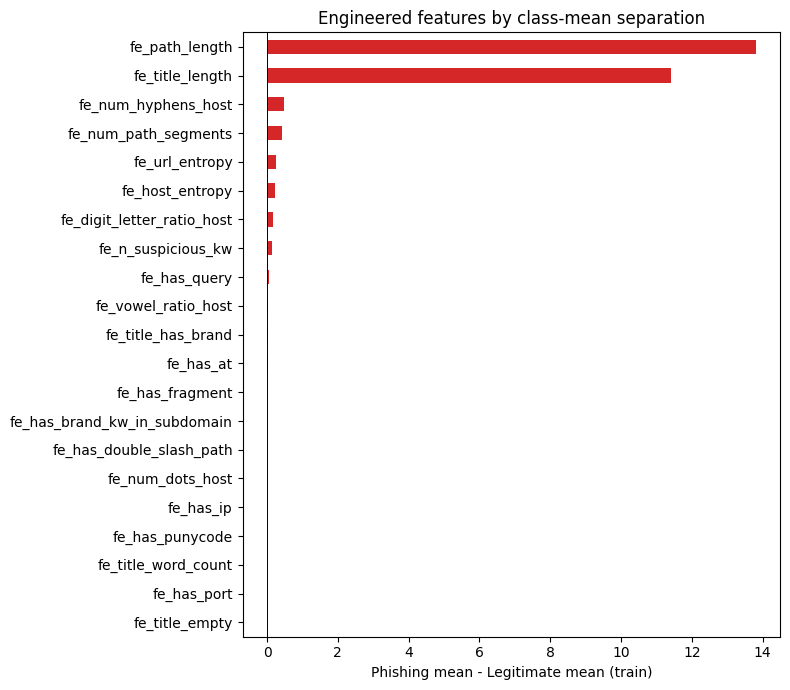

In [157]:
# bar chart of class-mean gaps
gap_sorted = by_class.sort_values('gap', key=lambda s: s.abs(), ascending=True)['gap']

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d62728' if v > 0 else '#2ca02c' for v in gap_sorted.values] # red = phish-leaning
gap_sorted.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Phishing mean - Legitimate mean (train)')
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('Engineered features by class-mean separation')
plt.tight_layout()
plt.show()

In [158]:
# add engineered features onto the selected-feature set, per split.
# drop URL/Domain/Title text columns now that we've extracted features from them.
def assemble(X_sel, eng):
  out = pd.concat([X_sel.reset_index(drop=True), eng.reset_index(drop=True)], axis=1)
  text_cols = [c for c in ['URL', 'Domain', 'Title'] if c in out.columns]
  if text_cols:
    out = out.drop(columns=text_cols)
  return out

X_train_final = assemble(X_train_selected, eng_train)
X_val_final = assemble(X_val_selected,   eng_val)
X_test_final = assemble(X_test_selected,  eng_test)

print(f"Final feature matrix shapes:")
print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")
print(f"({len(selected_features)} selected + {eng_train.shape[1]} engineered)")

Final feature matrix shapes:
X_train_final: (164992, 38)
X_val_final:   (35356, 38)
X_test_final:  (35356, 38)
(20 selected + 18 engineered)


PCA fit on train: 38 -> 24 components (95% variance retained)


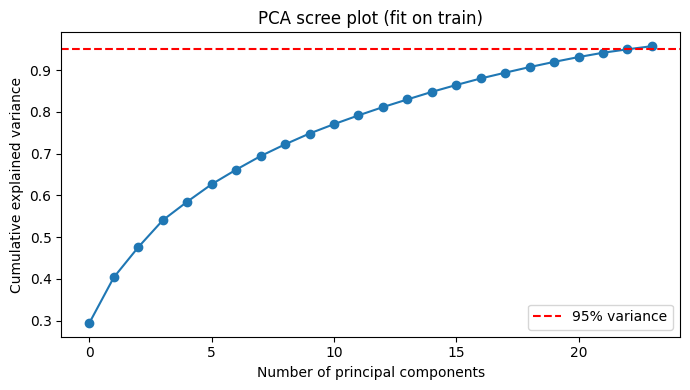

In [159]:
# PCA fit on TRAIN only, then applied to val and test
# no need to scale again because we already scaled above

from sklearn.decomposition import PCA

# fit PCA on train, transform all splits
pca = PCA(n_components=0.95, random_state=42).fit(X_train_final.fillna(0))
X_train_pca = pca.transform(X_train_final.fillna(0))
X_val_pca = pca.transform(X_val_final.fillna(0))
X_test_pca = pca.transform(X_test_final.fillna(0))

print(f"PCA fit on train: {X_train_final.shape[1]} -> {X_train_pca.shape[1]} components (95% variance retained)")

# scree-style plot from train
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA scree plot (fit on train)")
plt.legend()
plt.tight_layout()
plt.show()